In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv (r"C:\Users\aohab\OneDrive\Desktop\churn_prediction_system\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [6]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())
print(df.isnull().sum())    

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str   

In [7]:
df.drop('customerID', axis = 1, inplace = True )

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [9]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

C:\Users\aohab\AppData\Local\Temp\ipykernel_27944\2840544469.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [10]:
df.info()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [11]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", None)

# sometime we can use this code to replace the empty string with None, which will be treated as NaN in pandas.

# till here i have I removed non-informative features like customerID, converted TotalCharges to numeric format,
# and handled missing values using median imputation to maintain data integrity

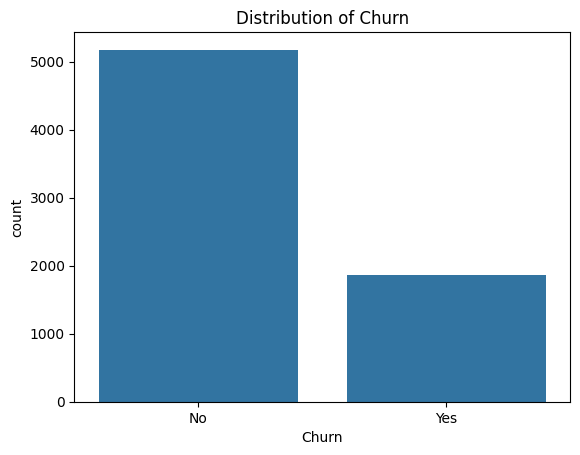

In [12]:
# Exploratory Data Analysis (EDA)

sns.countplot(x= "Churn", data=df)
plt.title("Distribution of Churn")
plt.show()

#this count how many customer stayed and how many left

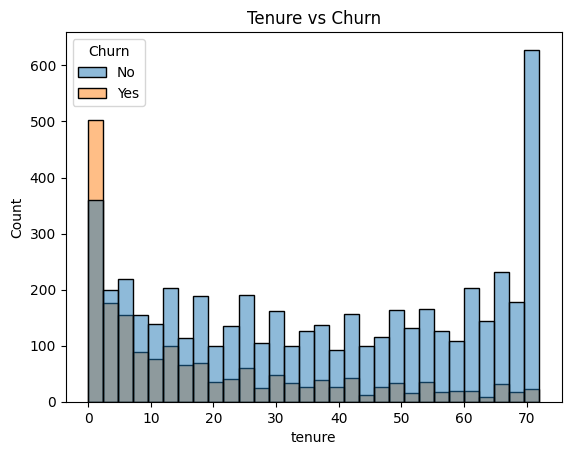

In [13]:
sns.histplot(data=df, x="tenure", hue="Churn", bins=30)
plt.title("Tenure vs Churn")
plt.show()

# This Shows How long customers stay before leaving

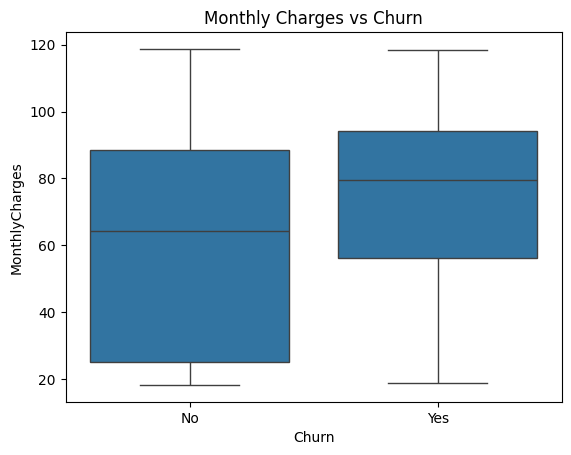

In [14]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()  

#this shows price impact on churn

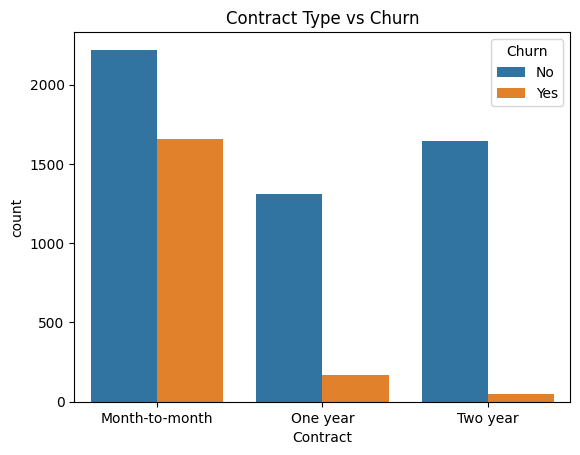

In [15]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")     
plt.show() 

# Contract duration effect

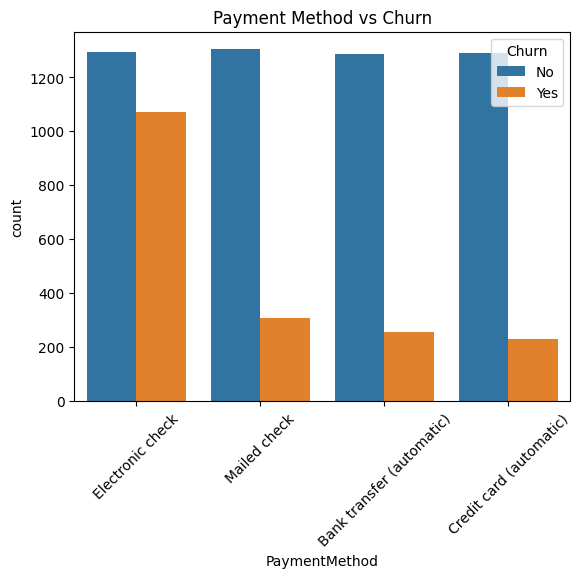

In [16]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()  

#electronic check user churns more 

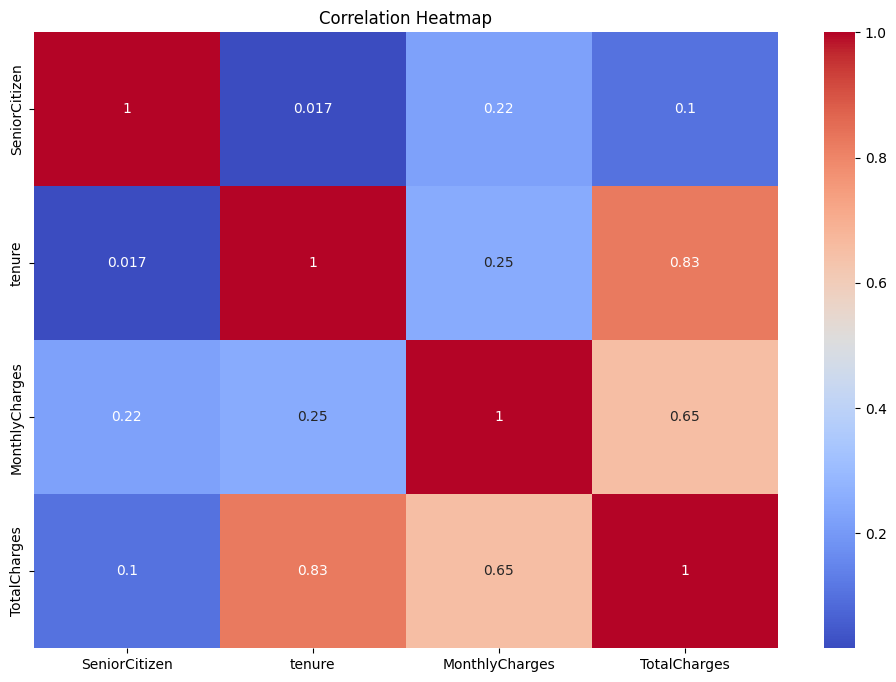

In [17]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [18]:
!pip install scikit-learn



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import sklearn
print("sklearn installed successfully")

sklearn installed successfully


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])
        
print(df.dtypes)

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [21]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [22]:
df = pd.get_dummies(df, drop_first=True)

In [23]:
print(df.dtypes)


SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes     

In [24]:
df = pd.get_dummies(df, drop_first=True)


In [25]:
print(df.isnull().sum())

SeniorCitizen                             0
tenure                                    0
MonthlyCharges                            0
TotalCharges                             11
Churn                                     0
gender_Male                               0
Partner_Yes                               0
Dependents_Yes                            0
PhoneService_Yes                          0
MultipleLines_No phone service            0
MultipleLines_Yes                         0
InternetService_Fiber optic               0
InternetService_No                        0
OnlineSecurity_No internet service        0
OnlineSecurity_Yes                        0
OnlineBackup_No internet service          0
OnlineBackup_Yes                          0
DeviceProtection_No internet service      0
DeviceProtection_Yes                      0
TechSupport_No internet service           0
TechSupport_Yes                           0
StreamingTV_No internet service           0
StreamingTV_Yes                 

In [26]:
df.fillna(df.median(), inplace=True)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,True,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,0,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,0,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,1,True,True,False,True,False,...,False,False,False,False,False,False,True,False,False,True


In [27]:
x = df.drop("Churn", axis=1)
y = df["Churn"]

In [28]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [29]:
print(x_train.isnull().sum().sum())

0


In [30]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test)

c:\Users\aohab\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.8211497515968772


In [32]:
from sklearn.ensemble import RandomForestClassifier 
rf = RandomForestClassifier()
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7913413768630234

Confusion Matrix:
 [[939  97]
 [197 176]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.86      1036
           1       0.64      0.47      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [34]:
#Random Forest achieved higher accuracy compared to Logistic Regression.
# However, recall for churn class is critical, as missing churn customers can lead to business loss. 
# Therefore, model performance was evaluated using multiple metrics beyond accuracy.

In [35]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.8211497515968772
Random Forest Accuracy: 0.7913413768630234


In [36]:
#FEATURE IMPORTANCE
import pandas as pd 
importance = pd.Series(rf.feature_importances_, index=x.columns)
importance = importance.sort_values(ascending=False)
print(importance.head(10))

TotalCharges                      0.192019
tenure                            0.174777
MonthlyCharges                    0.167776
InternetService_Fiber optic       0.041337
PaymentMethod_Electronic check    0.036123
gender_Male                       0.028746
Contract_Two year                 0.027667
OnlineSecurity_Yes                0.026443
PaperlessBilling_Yes              0.025868
TechSupport_Yes                   0.023633
dtype: float64


In [37]:
#Customers with high monthly charges churn more
#Low tenure customers churn more
#Long-term contracts reduce churn

In [38]:
import pickle 
pickle.dump(lr, open("churn_model.pkl", "wb"))  

#this will basically save model in a file called churn_model.pkl, 
# which can be loaded later for making predictions without retraining the model.

In [39]:
import pickle

model = pickle.load(open("churn_model.pkl","rb")) 

# it will Take one sample from test data
sample = x_test.iloc[0:1]

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Customer Will Churn")
else:
    print("Customer Will Stay")


Customer Will Churn


In [40]:
import pickle

pickle.dump(lr, open("churn_model.pkl", "wb"))

Accuracy: 0.8211497515968772


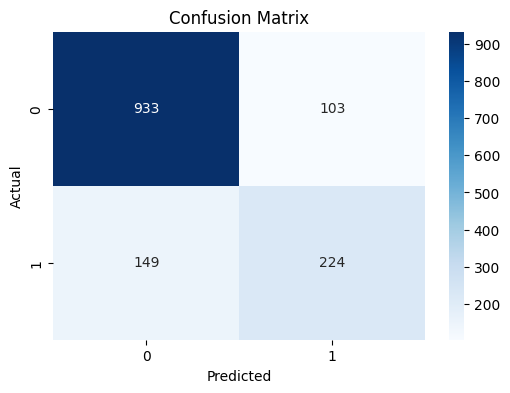


Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



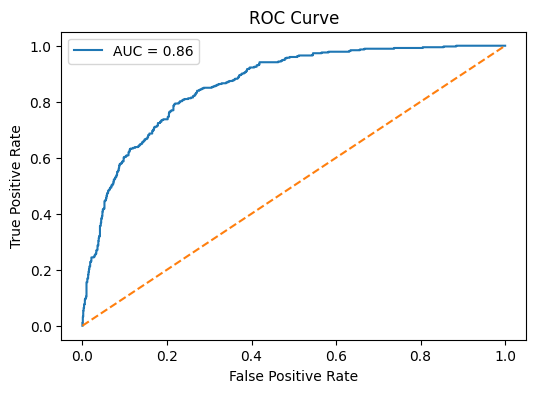

In [41]:
# -------------------------------
# MODEL EVALUATION
# -------------------------------

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:,1]

# -------------------------------
# 1. ACCURACY
# -------------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))


# -------------------------------
# 2. CONFUSION MATRIX
# -------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# -------------------------------
# 3. CLASSIFICATION REPORT
# -------------------------------
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# -------------------------------
# 4. ROC CURVE
# -------------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [42]:
import os
os.makedirs("reports", exist_ok=True)

plt.savefig("reports/confusion_matrix.png")
plt.savefig("reports/roc_curve.png")

<Figure size 640x480 with 0 Axes>

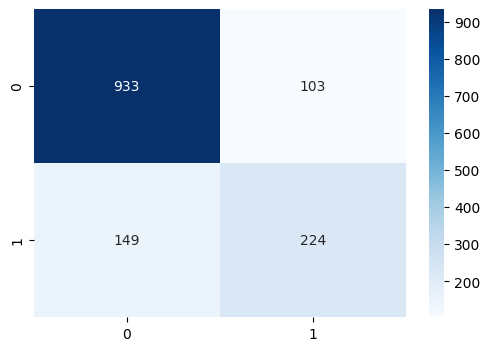

In [43]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.savefig("reports/confusion_matrix.png")
plt.show()

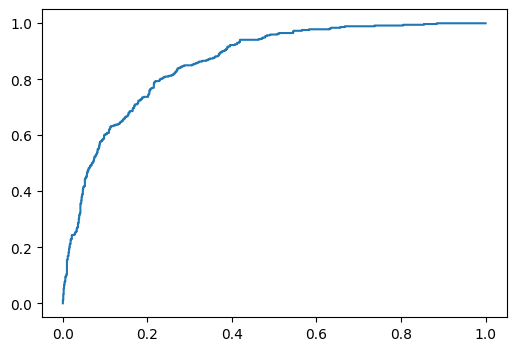

In [44]:
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.savefig("reports/roc_curve.png")
plt.show()

In [45]:
import pickle

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# Load model
model = pickle.load(open("churn_model.pkl", "rb"))

# Predictions
y_pred = model.predict(x_test)

# Probabilities
y_prob = model.predict_proba(x_test)[:,1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

Accuracy: 0.8211497515968772
Precision: 0.6850152905198776
Recall: 0.6005361930294906
F1 Score: 0.64
ROC AUC: 0.8623301106545074
